In [1]:
import hea
from hea.tidy import col
from hea.R import factor
from hea.models import gam
from hea.R import AIC, anova

## Replication of Figure 3 from Ran et al. (2020) 

### Receptive field sizes

In [2]:
data = hea.io.read_csv("https://raw.githubusercontent.com/berenslab/rgc_dendrites/refs/heads/master/data/processed/all_roi.csv")

data = (
    data
        .rename(
            soma_dist="dendritic_distance_to_soma", 
            rf_size="sRF_asd_upsampled_cntr_size_65",
            offset="cntrs_offset_calibrate_to_rois_65", 
            quality="cntr_quality"
        )
        .select("exp_date", "recording_id", "roi_id", "type", "soma_dist", "rf_size", "quality", "offset")
        .mutate(
            factor(data["exp_date"]),
            factor(data["type"], 
                labels={"0":"alpha transient", "1":"sustained", "2":"mini alpha", "3":"f-mini"}
            ), 
        )
        .filter((col("soma_dist") < 200))
        .filter(col("quality") == 1)
)

data

exp_date,recording_id,roi_id,type,soma_dist,rf_size,quality,offset
enum,i64,i64,enum,f64,f64,i64,f64
"""20161028_1""",0,0,"""alpha transient""",0.0,12.442011,1,12.809315
"""20161028_1""",1,1,"""alpha transient""",46.639967,10.099504,1,11.226635
"""20161028_1""",1,2,"""alpha transient""",34.984462,11.055209,1,6.573385
"""20161028_1""",1,3,"""alpha transient""",43.314967,11.048211,1,11.440616
"""20161028_1""",1,4,"""alpha transient""",69.875143,8.860962,1,5.762906
…,…,…,…,…,…,…,…
"""20180216_2""",5,5,"""f-mini""",135.294566,6.779088,1,48.884045
"""20180216_2""",5,6,"""f-mini""",116.090645,6.812224,1,34.875612
"""20180216_2""",5,7,"""f-mini""",131.010081,8.755394,1,44.422172


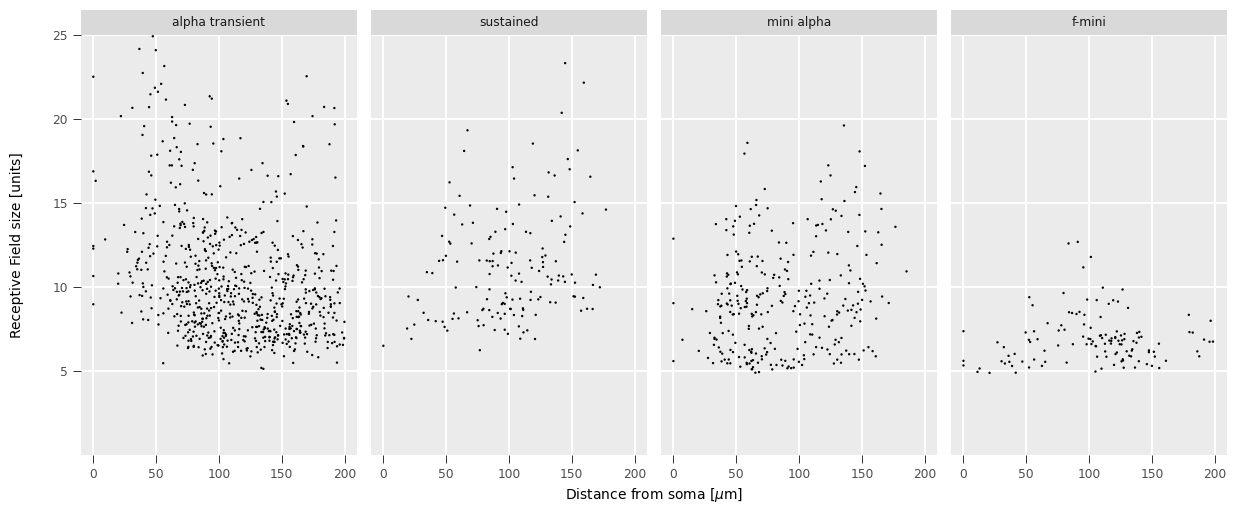

In [3]:
(
    data
        .ggplot(x="soma_dist", y="rf_size")
        .geom_point(alpha=1, shape=16, size=0.5)
        .facet_wrap("~type", ncol=4)
        .ylim([0, 25])
        # .theme_minimal()
        .labs(x=r"Distance from soma [$\mu$m]", y="Receptive Field size [units]")
).show(figsize=(12,5))

In [4]:
m1 = gam('rf_size ~ type + s(soma_dist, by=type, k=50)', data = data)
m1.summary()


Family: gaussian
Link function: identity

Formula: rf_size ~ type + s(soma_dist, by=type, k=50)

Parametric coefficients:
                Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)      10.9384      0.1315   83.167   < 2e-16  ***
typesustained     0.4065      0.3521    1.155     0.248
typemini alpha   -1.3627      0.2562   -5.318  1.23e-07  ***
typef-mini       -4.0205      0.3410  -11.789   < 2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                                     edf  Ref.df        F  p-value
s(soma_dist):typealpha transient  11.704  14.565  11.2966  < 2e-16  ***
s(soma_dist):typesustained         4.377   5.526   2.9041  0.01013  *
s(soma_dist):typemini alpha        1.012   1.025   7.4095  0.00620  **
s(soma_dist):typef-mini            1.833   2.307   0.3907  0.70625
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) = 0.203  Deviance explained = 21.6%
GCV = 12.473

In [5]:
m2 = gam('rf_size ~ type + s(soma_dist, by=type, k=50) + s(exp_date, bs="re")', data = data)
m2.summary()


Family: gaussian
Link function: identity

Formula: rf_size ~ type + s(soma_dist, by=type, k=50) + s(exp_date, bs="re")

Parametric coefficients:
                Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)      12.7394      0.9679  13.1616   < 2e-16  ***
typesustained    -1.4720      2.2130  -0.6652   0.50606
typemini alpha   -2.2966      2.0233  -1.1351   0.25656
typef-mini       -5.8777      2.0320  -2.8926   0.00389  **
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                                     edf  Ref.df        F   p-value
s(soma_dist):typealpha transient  10.628  13.241  21.5841   < 2e-16  ***
s(soma_dist):typesustained         4.821   6.094   2.6343  0.014732  *
s(soma_dist):typemini alpha        1.599   2.015   7.5682  0.000521  ***
s(soma_dist):typef-mini            1.806   2.265   0.5073  0.625214
s(exp_date)                       26.410  27.000  33.9193   < 2e-16  ***
---
Signif. codes: 0 '***' 0.0

In [6]:
AIC(m1, m2)

           df      AIC
m1  26.410232  7105.15
m2  54.107930  6437.74


In [7]:
anova(m1, m2, test="F")

Analysis of Deviance Table

m1: rf_size ~ type + s(soma_dist, by=type, k=50)
m2: rf_size ~ type + s(soma_dist, by=type, k=50) + s(exp_date, bs="re")

    Resid. Df  Resid. Dev       Df   Deviance        F      Pr(>F)
m1  1294.0941  15947.7026
m2  1265.5662   9238.5600  28.5279  6709.1425  32.4499  2.042e-129  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


<Axes: title={'center': 'Normal Q-Q'}, xlabel='Theoretical Quantiles', ylabel='Std. deviance resid.'>

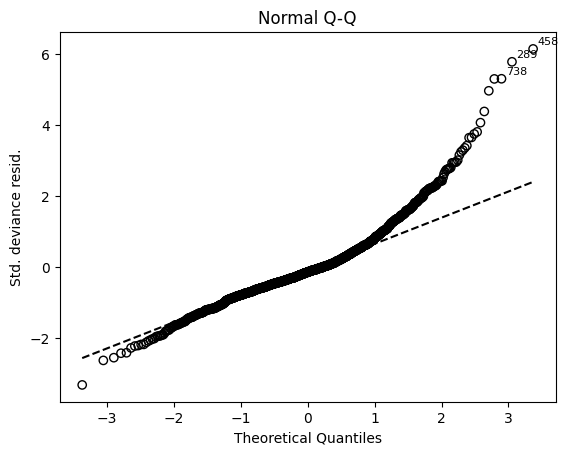

In [8]:
m2.plot_qq()

In [9]:
_ = m2.check()

Method: GCV.Cp   Optimizer: outer newton
full convergence after 7 iterations.
Gradient range [-2.089321e-09,9.741802e-07]
(score 7.527532 & scale 7.247437).
Hessian positive definite, eigenvalue range [0.001670258,0.013248].
Model rank = 231 / 231

Basis dimension (k) checking results. Low p-value (k-index<1) may
indicate that k is too low, especially if edf is close to k'.

                                     k'    edf  k-index  p-value
s(soma_dist):typealpha transient  49.00  10.63    0.974     0.14
s(soma_dist):typesustained        49.00   4.82    0.974     0.18
s(soma_dist):typemini alpha       49.00   1.60    0.974     0.19
s(soma_dist):typef-mini           49.00   1.81    0.974     0.19
s(exp_date)                       31.00  26.41      NaN      NaN
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


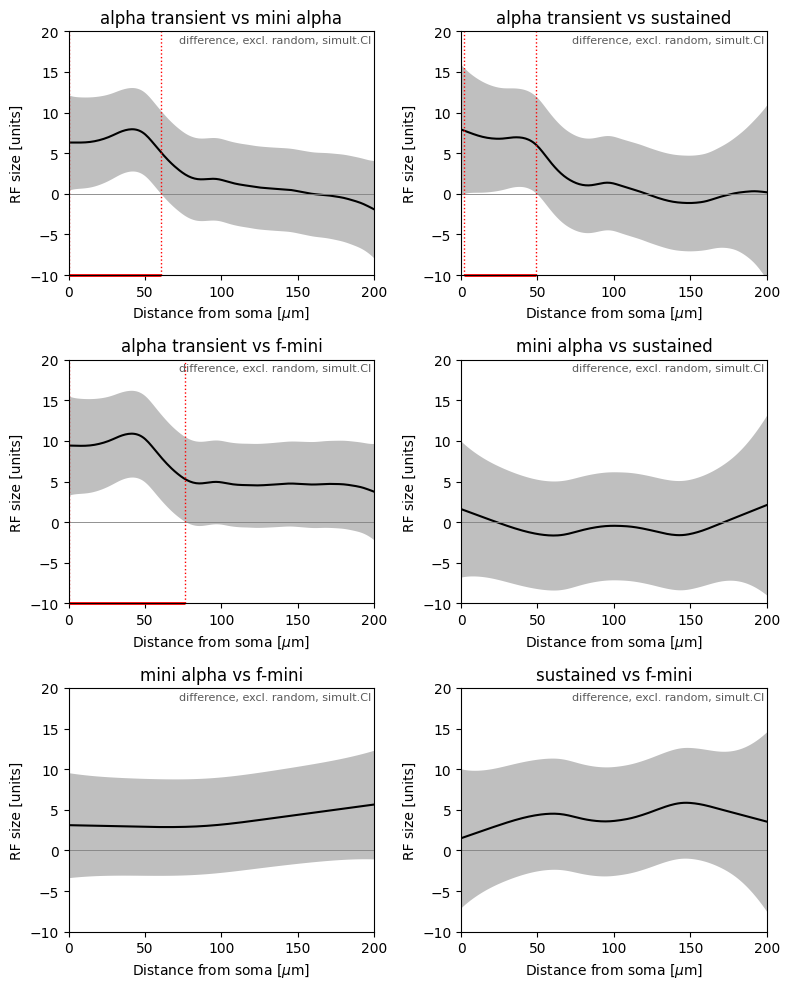

In [10]:
from itertools import combinations
import matplotlib.pyplot as plt

types = ["alpha transient", "mini alpha", "sustained", "f-mini"]

fig, axes = plt.subplots(3, 2, figsize=(8, 10))
for ax, (t, d) in zip(axes.ravel(), combinations(types, 2)):
    m2.plot_diff(
        view="soma_dist",
        comp={"type": (t, d)},
        sim_ci=True,
        rm_ranef=True,
        print_summary=False,
        hide_label=False,
        xlab=r"Distance from soma [$\mu$m]",
        ylab="RF size [units]",
        title=f"{t} vs {d}",
        xlim=(0, 200),
        ylim=(-10, 20),
        ax=ax,
    )
fig.tight_layout()
plt.show()

### Receptive field offset

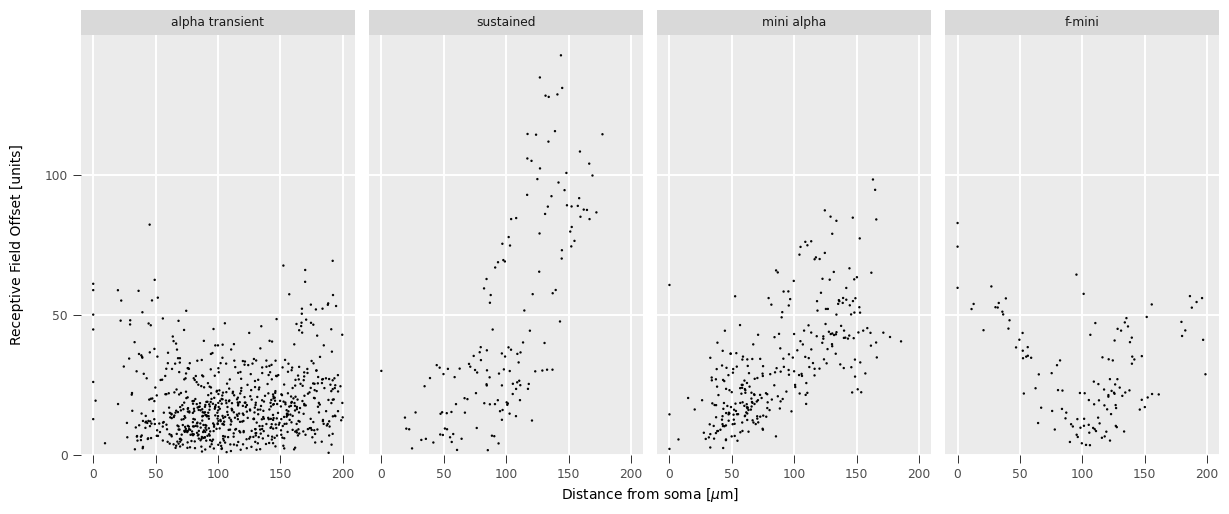

In [11]:
(
    data
        .ggplot(x="soma_dist", y="offset")
        .geom_point(alpha=1, shape=16, size=0.5)
        .facet_wrap("~type", ncol=4)
        .ylim([0, 150])
        # .theme_minimal()
        .labs(x=r"Distance from soma [$\mu$m]", y="Receptive Field Offset [units]")
).show(figsize=(12,5))

In [12]:
n1 = gam('offset ~ type + s(soma_dist, by=type, k=50)', data = data)
n1.summary()


Family: gaussian
Link function: identity

Formula: offset ~ type + s(soma_dist, by=type, k=50)

Parametric coefficients:
                Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)      19.1890      0.5817   32.986   < 2e-16  ***
typesustained    32.7949      1.8387   17.836   < 2e-16  ***
typemini alpha   18.0987      1.2350   14.654   < 2e-16  ***
typef-mini       10.3840      1.5655    6.633  4.82e-11  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                                    edf  Ref.df      F   p-value
s(soma_dist):typealpha transient  3.086   3.905  10.45  3.44e-08  ***
s(soma_dist):typesustained        7.713   9.651  54.36   < 2e-16  ***
s(soma_dist):typemini alpha       3.965   5.029  42.24   < 2e-16  ***
s(soma_dist):typef-mini           3.413   4.262  18.28  2.13e-15  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) = 0.51  Deviance explained = 51.7%
GCV = 247.9

In [13]:
n2 = gam('offset ~ type + s(soma_dist, by=type, k=50) + s(exp_date, bs="re")', data = data)
n2.summary()


Family: gaussian
Link function: identity

Formula: offset ~ type + s(soma_dist, by=type, k=50) + s(exp_date, bs="re")

Parametric coefficients:
                Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)       24.396       2.602   9.3763   < 2e-16  ***
typesustained     23.990       6.039   3.9725  7.51e-05  ***
typemini alpha    12.717       5.415   2.3483    0.0190  *
typef-mini         4.088       5.493   0.7443    0.4568
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                                     edf  Ref.df      F   p-value
s(soma_dist):typealpha transient   3.341   4.227  11.78  8.37e-10  ***
s(soma_dist):typesustained         9.686  12.062  53.49   < 2e-16  ***
s(soma_dist):typemini alpha        4.349   5.513  50.12   < 2e-16  ***
s(soma_dist):typef-mini            4.114   5.115  23.18   < 2e-16  ***
s(exp_date)                       24.916  27.000  13.52   < 2e-16  ***
---
Signif. codes: 0 '***' 0.001

In [14]:
AIC(n1, n2)

           df       AIC
n1  23.195201  11058.74
n2  51.440819  10756.39


In [15]:
anova(n1,n2, test="F")

Analysis of Deviance Table

n1: offset ~ type + s(soma_dist, by=type, k=50)
n2: offset ~ type + s(soma_dist, by=type, k=50) + s(exp_date, bs="re")

    Resid. Df   Resid. Dev     Df    Deviance        F     Pr(>F)
n1  1297.1349  317431.8590
n2  1266.3050  242073.1797  30.83  75358.6793  12.8601  1.556e-55  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


<Axes: title={'center': 'Normal Q-Q'}, xlabel='Theoretical Quantiles', ylabel='Std. deviance resid.'>

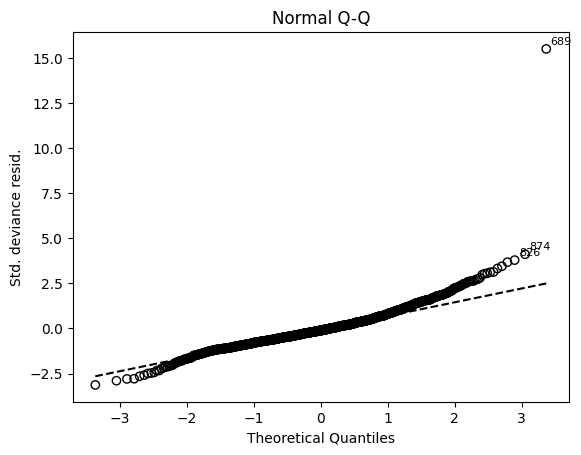

In [16]:
n2.plot_qq()

In [17]:
n2.check()

Method: GCV.Cp   Optimizer: outer newton
full convergence after 8 iterations.
Gradient range [-5.040425e-08,1.416845e-05]
(score 197.594 & scale 190.0711).
Hessian positive definite, eigenvalue range [0.08396847,0.5078922].
Model rank = 231 / 231

Basis dimension (k) checking results. Low p-value (k-index<1) may
indicate that k is too low, especially if edf is close to k'.

                                     k'    edf  k-index  p-value
s(soma_dist):typealpha transient  49.00   3.34     1.01     0.56
s(soma_dist):typesustained        49.00   9.69     1.01     0.55
s(soma_dist):typemini alpha       49.00   4.35     1.01     0.58
s(soma_dist):typef-mini           49.00   4.11     1.01     0.55
s(exp_date)                       31.00  24.92      NaN      NaN
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


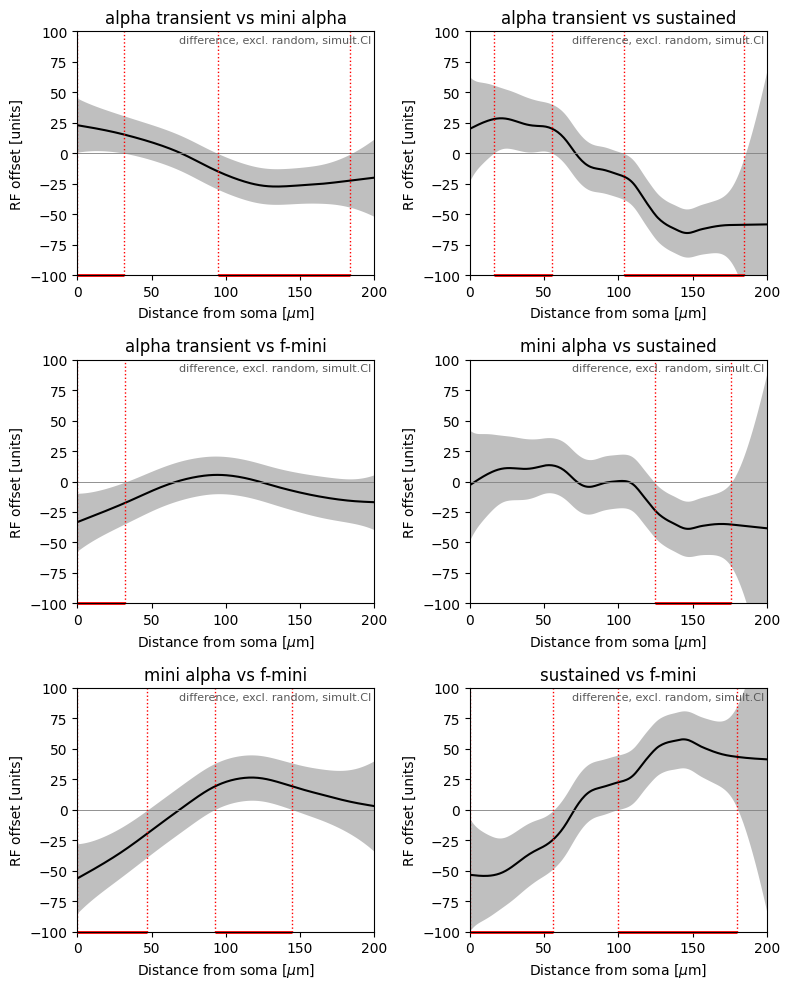

In [18]:
from itertools import combinations
import matplotlib.pyplot as plt

types = ["alpha transient", "mini alpha", "sustained", "f-mini"]

fig, axes = plt.subplots(3, 2, figsize=(8, 10))
for ax, (t, d) in zip(axes.ravel(), combinations(types, 2)):
    n2.plot_diff(
        view="soma_dist",
        comp={"type": (t, d)},
        sim_ci=True,
        rm_ranef=True,
        print_summary=False,
        hide_label=False,
        xlab=r"Distance from soma [$\mu$m]",
        ylab="RF offset [units]",
        title=f"{t} vs {d}",
        xlim=(0, 200),
        ylim=(-100, 100),
        ax=ax,
    )
fig.tight_layout()
plt.show()

In [ ]:
from hea import session_info
session_info()